# Description
This script compares cest values of regions within network vs between network.


## Import Packages

In [1]:
import os
import glob
import numpy as np
import pandas as pd
#import network_fcon as fc
import scipy as sp
from scipy.stats import pearsonr
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt
import re
import seaborn as sns
import statsmodels.formula.api as smf
from netneurotools import datasets, plotting
from nilearn.datasets import fetch_atlas_schaefer_2018
from netneurotools.datasets import fetch_cammoun2012

### Set Variables and Paths

In [4]:
# Set Variables
dataset = 'longglucest_outputmeasures2'
atlas = 'Schaefer2018_1000Parcels_17Networks' #'atl-Cammoun2012_res-500' #
inpath = "/Users/pecsok/Desktop/ImageData/PMACS_remote/data/nmaps/analyses/" + atlas
nmaps = ["NMDA", "mGluR5", "GABA","SAaxis"]

# Import Data
means_df = pd.read_csv(inpath + '/means_std_' + dataset + '_' + atlas + '.csv')

# Set Altas Parameters
if atlas == 'schaefer':
    schaefer = fetch_atlas_schaefer_2018(n_rois=1000, yeo_networks=17) # This is sklearn.utils._bunch.Bunch. Other altases in this format? *Ask Golia
    nnodes = len(schaefer['labels'])
elif atlas == 'atl-Cammoun2012_res-500':
    scale = 'cammoun2012_scale500' #'scale1000_17' #'Harvard_Oxford_sub' 
    cammoun = fetch_cammoun2012()
    nnodes=1015
elif atlas == 'Harvard_Oxford_sub':
    nnodes = 21



In [8]:
# Import CB1 
receptors_all = pd.read_csv('/Users/pecsok/projects/Neuromaps/pecsok_pfns/neuromaps/results/receptor_data_all_cammoun2012_scale500.csv')




path+'results/receptor_data_all_'+scale+'.csv'

FileNotFoundError: [Errno 2] No such file or directory: '/Users/pecsok/projects/Neuromaps/pecsok_pfns/neuromaps/results/receptor_data_all_cammoun2012_scale500.csv'

In [6]:
receptors_all


'/Users/pecsok/projects/Neuromaps/pecsok_pfns/neuromaps/results/receptor_data_all_cammoun2012_scale500.csv'

In [3]:
# Load and curate atlas-specific data
if atlas == 'atl-Cammoun2012_res-500':
    # Load in Parcel Labels
    cam = fetch_cammoun2012()
    info = pd.read_csv(cam['info'], sep=',')
    info = info[info['scale']== 'scale500']
    labels = info['label'][info['structure']=='subcortex'] # list of just cortical ROIs
    print(labels)
    # Load in receptor df
    receptor_df = pd.read_csv("/Users/pecsok/projects/Neuromaps/pecsok_pfns/neuromaps/results/receptor_data_cammoun2012_scale500.csv", sep=',')
    receptor_df.rename(columns={'GABAa': 'GABA'}, inplace=True)   
    # Remove subcortical Parcels from receptor_df and means_df
    receptor_df = receptor_df[~receptor_df['Parcel'].str.contains('|'.join(labels))]
    means_df = means_df[~means_df['Parcel'].str.contains('|'.join(labels))]

elif atlas == 'Schaefer2018_1000Parcels_17Networks':
    # Fetch Schaefer 2018 atlas coordinates (for example)
    schaefer = fetch_atlas_schaefer_2018(n_rois=1000, yeo_networks=17)
    labels = schaefer['labels']  # These are the MNI coordinates of the parcels
    labels = [label.decode('utf-8') for label in labels]
    receptor_df = pd.read_csv("/Users/pecsok/projects/Neuromaps/pecsok_pfns/neuromaps/results/receptor_data_scale1000_17.csv", sep=',')
    receptor_df.rename(columns={'GABAa': 'GABA'}, inplace=True)
    receptor_df['Parcel'] = labels
    

### NMAP correlations

In [4]:
from scipy.stats import spearmanr
correlation, p_value = spearmanr(means_df['SAaxis'], means_df['CEST_avg'])
print(correlation)
print(p_value)

-0.5534197192859724
4.065828261165388e-12


In [1]:
print(means_df)
nmap_palette = {
    "NMDA": "Purples",   # Replace with actual nmap names and desired palettes
    "mGluR5": "Reds",
    "GABA": "Greens",
    "SAaxis": "Oranges"
    # Add more mappings as needed
}

for nmap in nmaps:
    #means_df[nmap] = pd.to_numeric(means_df[nmap], errors='coerce')
    #means_df['CESTavg'] = pd.to_numeric(means_df['CESTavg'], errors='coerce')
    graph_df = means_df  #.dropna(subset=[nmap, 'CESTavg'])
    palette = nmap_palette.get(nmap) # Default to "Set1" if nmap not in dictionary
    plot = sns.lmplot(x=nmap, y='CEST_avg', hue='hstatus', data=graph_df, palette=palette)
    plt.figure(figsize=(12, 4.7), dpi=300)
    plt.xlabel(nmap)
    plt.ylabel("CESTavg")
    plt.title('Linear Regression between ' + nmap + ' and CEST')
    
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['hstatus'] == 'PSY', 'CEST_avg'], graph_df.loc[graph_df['hstatus'] == 'PSY', nmap])
    plt.text(0.1, 0.8, f'PSY Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['hstatus'] == 'HC', 'CEST_avg'], graph_df.loc[graph_df['hstatus'] == 'HC', nmap])
    plt.text(0.4, 0.8, f'HC Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)
    slope, intercept, r_value, p_value, std_err = linregress(graph_df['CEST_avg'], graph_df[nmap])
    plt.text(0.7, 0.8, f'All Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)
    plt.show() 


NameError: name 'means_df' is not defined

                               Parcel hstatus  CEST_avg      NMDA    mGluR5  \
0         17Networks_RH_ContA_Cingm_1      HC -0.239851 -0.861131 -1.573938   
1         17Networks_RH_ContA_Cingm_1     PSY -0.235165 -0.861131 -1.573938   
2         17Networks_RH_ContA_Cingm_2      HC -0.255432 -0.970507 -1.450434   
3         17Networks_RH_ContA_Cingm_2     PSY -0.260417 -0.970507 -1.450434   
4         17Networks_RH_ContB_PFCmp_1      HC -0.102085  1.266783  1.540954   
..                                ...     ...       ...       ...       ...   
129  17Networks_RH_VisPeri_ExStrSup_7     PSY  0.450614  0.725344  0.649158   
130   17Networks_RH_VisPeri_StriCal_3      HC  1.342156  1.396886 -0.190620   
131   17Networks_RH_VisPeri_StriCal_3     PSY  1.096243  1.396886 -0.190620   
132   17Networks_RH_VisPeri_StriCal_5      HC  1.024538  1.191815 -0.072134   
133   17Networks_RH_VisPeri_StriCal_5     PSY  0.917279  1.191815 -0.072134   

         GABA  SAaxis  
0   -0.950374   460.0  
1  

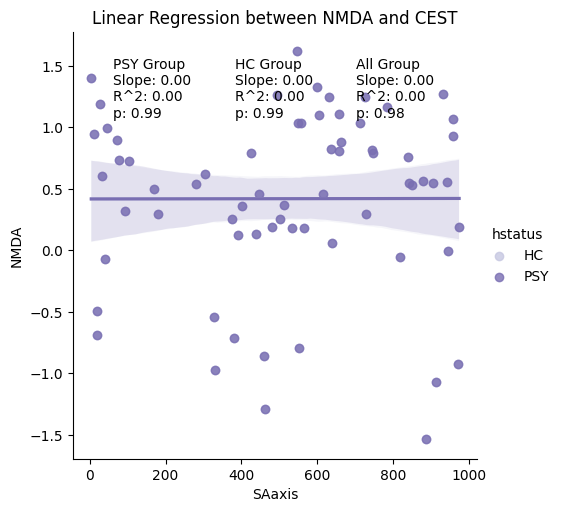

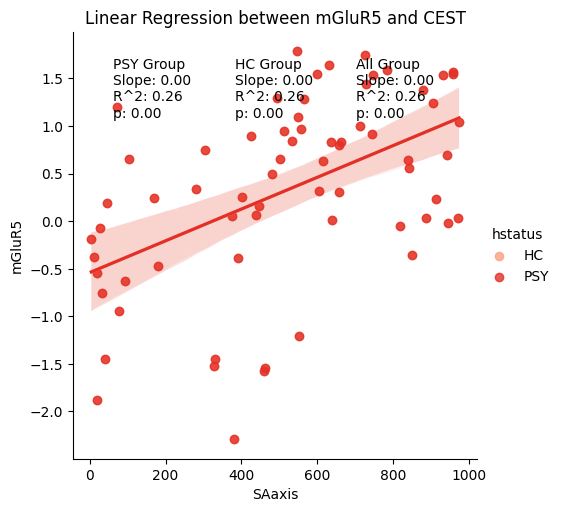

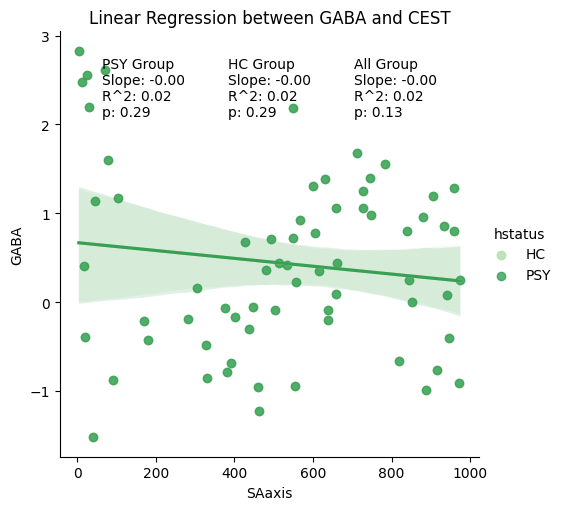

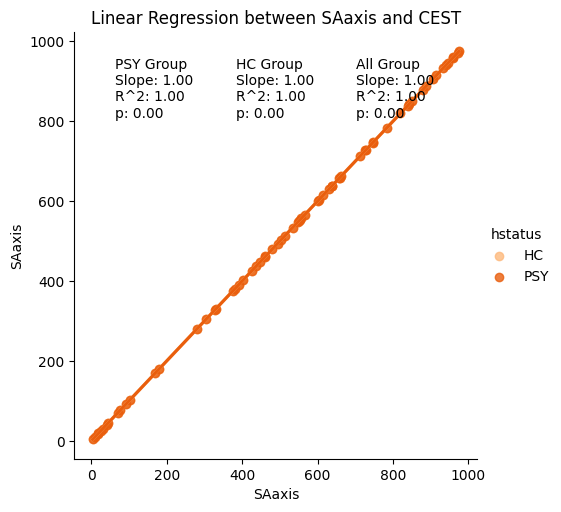

In [8]:
print(means_df)
nmap_palette = {
    "NMDA": "Purples",   # Replace with actual nmap names and desired palettes
    "mGluR5": "Reds",
    "GABA": "Greens",
    "SAaxis": "Oranges"
    # Add more mappings as needed
}

for nmap in nmaps:
    #means_df[nmap] = pd.to_numeric(means_df[nmap], errors='coerce')
    #means_df['CESTavg'] = pd.to_numeric(means_df['CESTavg'], errors='coerce')
    graph_df = means_df  #.dropna(subset=[nmap, 'CESTavg'])
    palette = nmap_palette.get(nmap) # Default to "Set1" if nmap not in dictionary
    plot = sns.lmplot(x='SAaxis', y=nmap, hue='hstatus', data=graph_df, palette=palette)
    plt.xlabel('SAaxis')
    plt.ylabel(nmap)
    plt.title('Linear Regression between ' + nmap + ' and CEST')
    
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['hstatus'] == 'PSY', 'SAaxis'], graph_df.loc[graph_df['hstatus'] == 'PSY', nmap])
    plt.text(0.1, 0.8, f'PSY Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['hstatus'] == 'HC', 'SAaxis'], graph_df.loc[graph_df['hstatus'] == 'HC', nmap])
    plt.text(0.4, 0.8, f'HC Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)
    slope, intercept, r_value, p_value, std_err = linregress(graph_df['SAaxis'], graph_df[nmap])
    plt.text(0.7, 0.8, f'All Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)
    plt.show() 

In [7]:
# Now try to generate some null models.
# Import Data
means_df_hc = means_df[means_df['hstatus']=="HC"]

#grp_df = pd.read_csv(inpath + '/grp_df_' + dataset + atlas + '.csv')
#print(grp_df)

# Function to create null dataframes with cyclic shifts for specified columns
def create_null_dfs(df, nmaps, n_shifts):
    null_dfs = []
    for _ in range(n_shifts):
        null_df = df.copy()
        
        # Random shift between 1 and len(df)
        random_shift = np.random.randint(1, len(df))
        
        # Apply the cyclic shift to each column in nmaps
        for col in nmaps:
            # Perform a true cyclic shift
            null_df[col] = np.roll(df[col].values, random_shift)
        
        null_dfs.append(null_df)
    return null_dfs

# Get the number of rows in the dataframe
null_dfs = create_null_dfs(means_df_hc, nmaps, 1000)
print(null_dfs[4])

                          Parcel hstatus  CEST_avg      NMDA    mGluR5  \
0     caudalanteriorcingulate_5R      HC  0.140048  0.540498  1.204780   
2                      cuneus_3R      HC  0.884299  0.700920  1.659291   
4                      cuneus_5R      HC  1.411665 -0.244781  0.447170   
6                 frontalpole_1R      HC -0.475798  0.900524  1.696054   
8            isthmuscingulate_1R      HC  0.265007  0.532322  0.770870   
10           isthmuscingulate_2R      HC  0.592127 -0.262348 -0.484805   
12           isthmuscingulate_3R      HC  0.098472 -0.392232 -0.032582   
14           isthmuscingulate_4R      HC  0.246605  0.765280  0.672350   
16                   lingual_11R      HC  1.179280 -0.539328  0.194108   
18                   lingual_13R      HC  1.987714 -1.089619  0.456369   
20               paracentral_11R      HC -0.106498  0.739121  1.834678   
22               paracentral_12R      HC -0.348940 -0.331275 -0.129873   
24                paracentral_2R      

In [9]:
# Function to calculate correlation stats for each null iteration and store in a final dataframe
def calculate_shift_correlations(null_dfs, nmaps):
    # Initialize an empty dataframe to store the results
    columns = ['shift_iteration']
    for col in nmaps:
        columns.append(f'{col}_r')
        columns.append(f'{col}_p')
    
    null_stats_df = pd.DataFrame(columns=columns)
    
    # Loop through each null dataframe (each shift iteration)
    for i, null_df in enumerate(null_dfs):
        result_row = {'shift_iteration': i + 1}
        
        # For each nmaps column, calculate r and p values with respect to CESTavg
        for col in nmaps:
            r_value, p_value = pearsonr(null_df['CEST_avg'], null_df[col])
            result_row[f'{col}_r'] = r_value
            result_row[f'{col}_p'] = p_value
        
        # Convert result_row to a DataFrame and concatenate it
        result_row_df = pd.DataFrame([result_row])
        null_stats_df = pd.concat([null_stats_df, result_row_df], ignore_index=True)
    
    return null_stats_df

# Example usage with the list of null dataframes (e.g., null_dfs)
null_stats_df = calculate_shift_correlations(null_dfs, nmaps)

# Display the final dataframe with r and p values for each shift iteration
print(null_stats_df)

/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_14135/1002016908.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  null_stats_df = pd.concat([null_stats_df, result_row_df], ignore_index=True)


    shift_iteration    NMDA_r    NMDA_p  mGluR5_r  mGluR5_p    GABA_r  \
0                 1  0.112111  0.428775  0.265324  0.057302  0.215045   
1                 2  0.303148  0.028919 -0.085220  0.548052  0.157882   
2                 3  0.032560  0.818755  0.093730  0.508660  0.305802   
3                 4  0.073789  0.603153  0.199205  0.156834  0.053533   
4                 5 -0.045814  0.747068 -0.084851  0.549788 -0.102244   
..              ...       ...       ...       ...       ...       ...   
995             996 -0.099148  0.484356 -0.296359  0.032900 -0.244308   
996             997  0.128776  0.362908  0.390544  0.004204  0.316545   
997             998  0.185259  0.188557 -0.224720  0.109234 -0.066135   
998             999  0.162147  0.250782  0.070048  0.621692  0.069975   
999            1000 -0.170326  0.227346  0.053526  0.706273 -0.124937   

       GABA_p  
0    0.125773  
1    0.263627  
2    0.027477  
3    0.706234  
4    0.470748  
..        ...  
995  0.0809

In [11]:
## Significance Testing
# Real correlation computation
def calculate_real_correlations(df, nmaps):
    real_corrs = {}
    for col in nmaps:
        r_value, _ = pearsonr(df['CEST_avg'], df[col])
        real_corrs[col] = r_value
    return real_corrs

# Compare real correlations to the null distribution to calculate empirical p-values
def calculate_empirical_pvalues(real_corrs, null_stats_df, nmaps):
    p_values = {}
    
    # Loop through each column in nmaps
    for col in nmaps:
        # Extract the null r-values for this nmaps column
        null_r_values = null_stats_df[f'{col}_r']
        
        # Calculate the empirical p-value: proportion of null r-values more extreme than the real r-value
        real_r = real_corrs[col]
        
        # Golia's addition
        null_mean = null_r_values.mean() # Find mean of r nulls
        # Subtract mean from null and real r values.
        null_r_values = null_r_values - null_mean 
        real_r = real_r - null_mean
        
        # Two-tailed test: count both large positive and negative extremes
        extreme_count = np.sum(np.abs(null_r_values) >= np.abs(real_r))
        
        # Compute the empirical p-value
        p_empirical = (extreme_count + 1) / (len(null_r_values)+ 1) # Fix add +1 to both sides of fraction because 
        p_values[col] = p_empirical
    
    return p_values

# Example usage with the original (unshifted) dataframe `df` and null distribution `null_stats_df`
real_corrs = calculate_real_correlations(means_df_hc, nmaps)
empirical_p_values = calculate_empirical_pvalues(real_corrs, null_stats_df, nmaps)

print(real_corrs)
for col, p_val in empirical_p_values.items():
    print(f'{col}: {p_val:.10f}') 

{'NMDA': 0.4755258399370453, 'mGluR5': 0.22589118396115393, 'GABA': 0.6970255086107258}
NMDA: 0.0009990010
mGluR5: 0.2047952048
GABA: 0.0009990010


In [33]:
# Repeat. Now do something similar, but shift all parcel values in cortex
#    
# First, shift the 1000 parcels by a random amount
null_dfs = create_null_dfs(receptor_df, nmaps, 1000)

# Keep only parcels in slice
means_cest = means_df_hc[['Parcel','hstatus', 'CESTavg']]
filtered_merged_dfs = []
for null_df in null_dfs:
    merged_df2 = means_cest.merge(null_df, on='Parcel', how='inner')
    filtered_merged_dfs.append(merged_df2)

# Example usage with the original (unshifted) dataframe `df` and null distribution `null_stats_df`
#real_corrs = calculate_real_correlations(means_df_hc, nmaps)
null_stats_df2 = calculate_shift_correlations(filtered_merged_dfs, nmaps)
empirical_p_values2 = calculate_empirical_pvalues(real_corrs, null_stats_df2, nmaps)


/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_92679/2564279690.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  null_stats_df = pd.concat([null_stats_df, result_row_df], ignore_index=True)


In [34]:
print(empirical_p_values2)

{'NMDA': 0.016, 'mGluR5': 0.295, 'GABA': 0.0}
